# 电商购物车流失分析：总结与业务建议

> **项目**：eCommerce Events History（化妆品电商，2019年12月）  
> **核心问题**：用户加购后为什么不买？到底是谁在流失？  
> **数据规模**：100万+ 事件记录，166 个品牌  
> **分析方法**：漏斗分析 → 排除法（价格/品牌/时间） → 交叉验证  

---

## 分析路线图

```
发现购物车流失严重（notebook 02）
    → 价格不是原因（notebook 03，AB对比无差异）
    → 品牌才是根本差异（notebook 04，品牌ABC分析）
    → 时间交叉验证：时间有影响但非根因（notebook 05，时间交叉分析）
    → 控制价格后品牌差异依然存在（notebook 06，价格品类分析）
    → 本文件：总结结论 + 业务建议
```

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# 图表风格（必须先设置，否则会覆盖后面的字体配置）
plt.style.use('seaborn-v0_8-whitegrid')

# 中文字体设置（放在 style.use 之后）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

COLORS = {'A': '#2ecc71', 'B': '#f39c12', 'C': '#e74c3c'}

---
## 发现一：购物车是全站最大的流失黑洞

> 来源：`notebook 02 - 浏览加入购物车购买转化`  
> 数据：全量事件统计

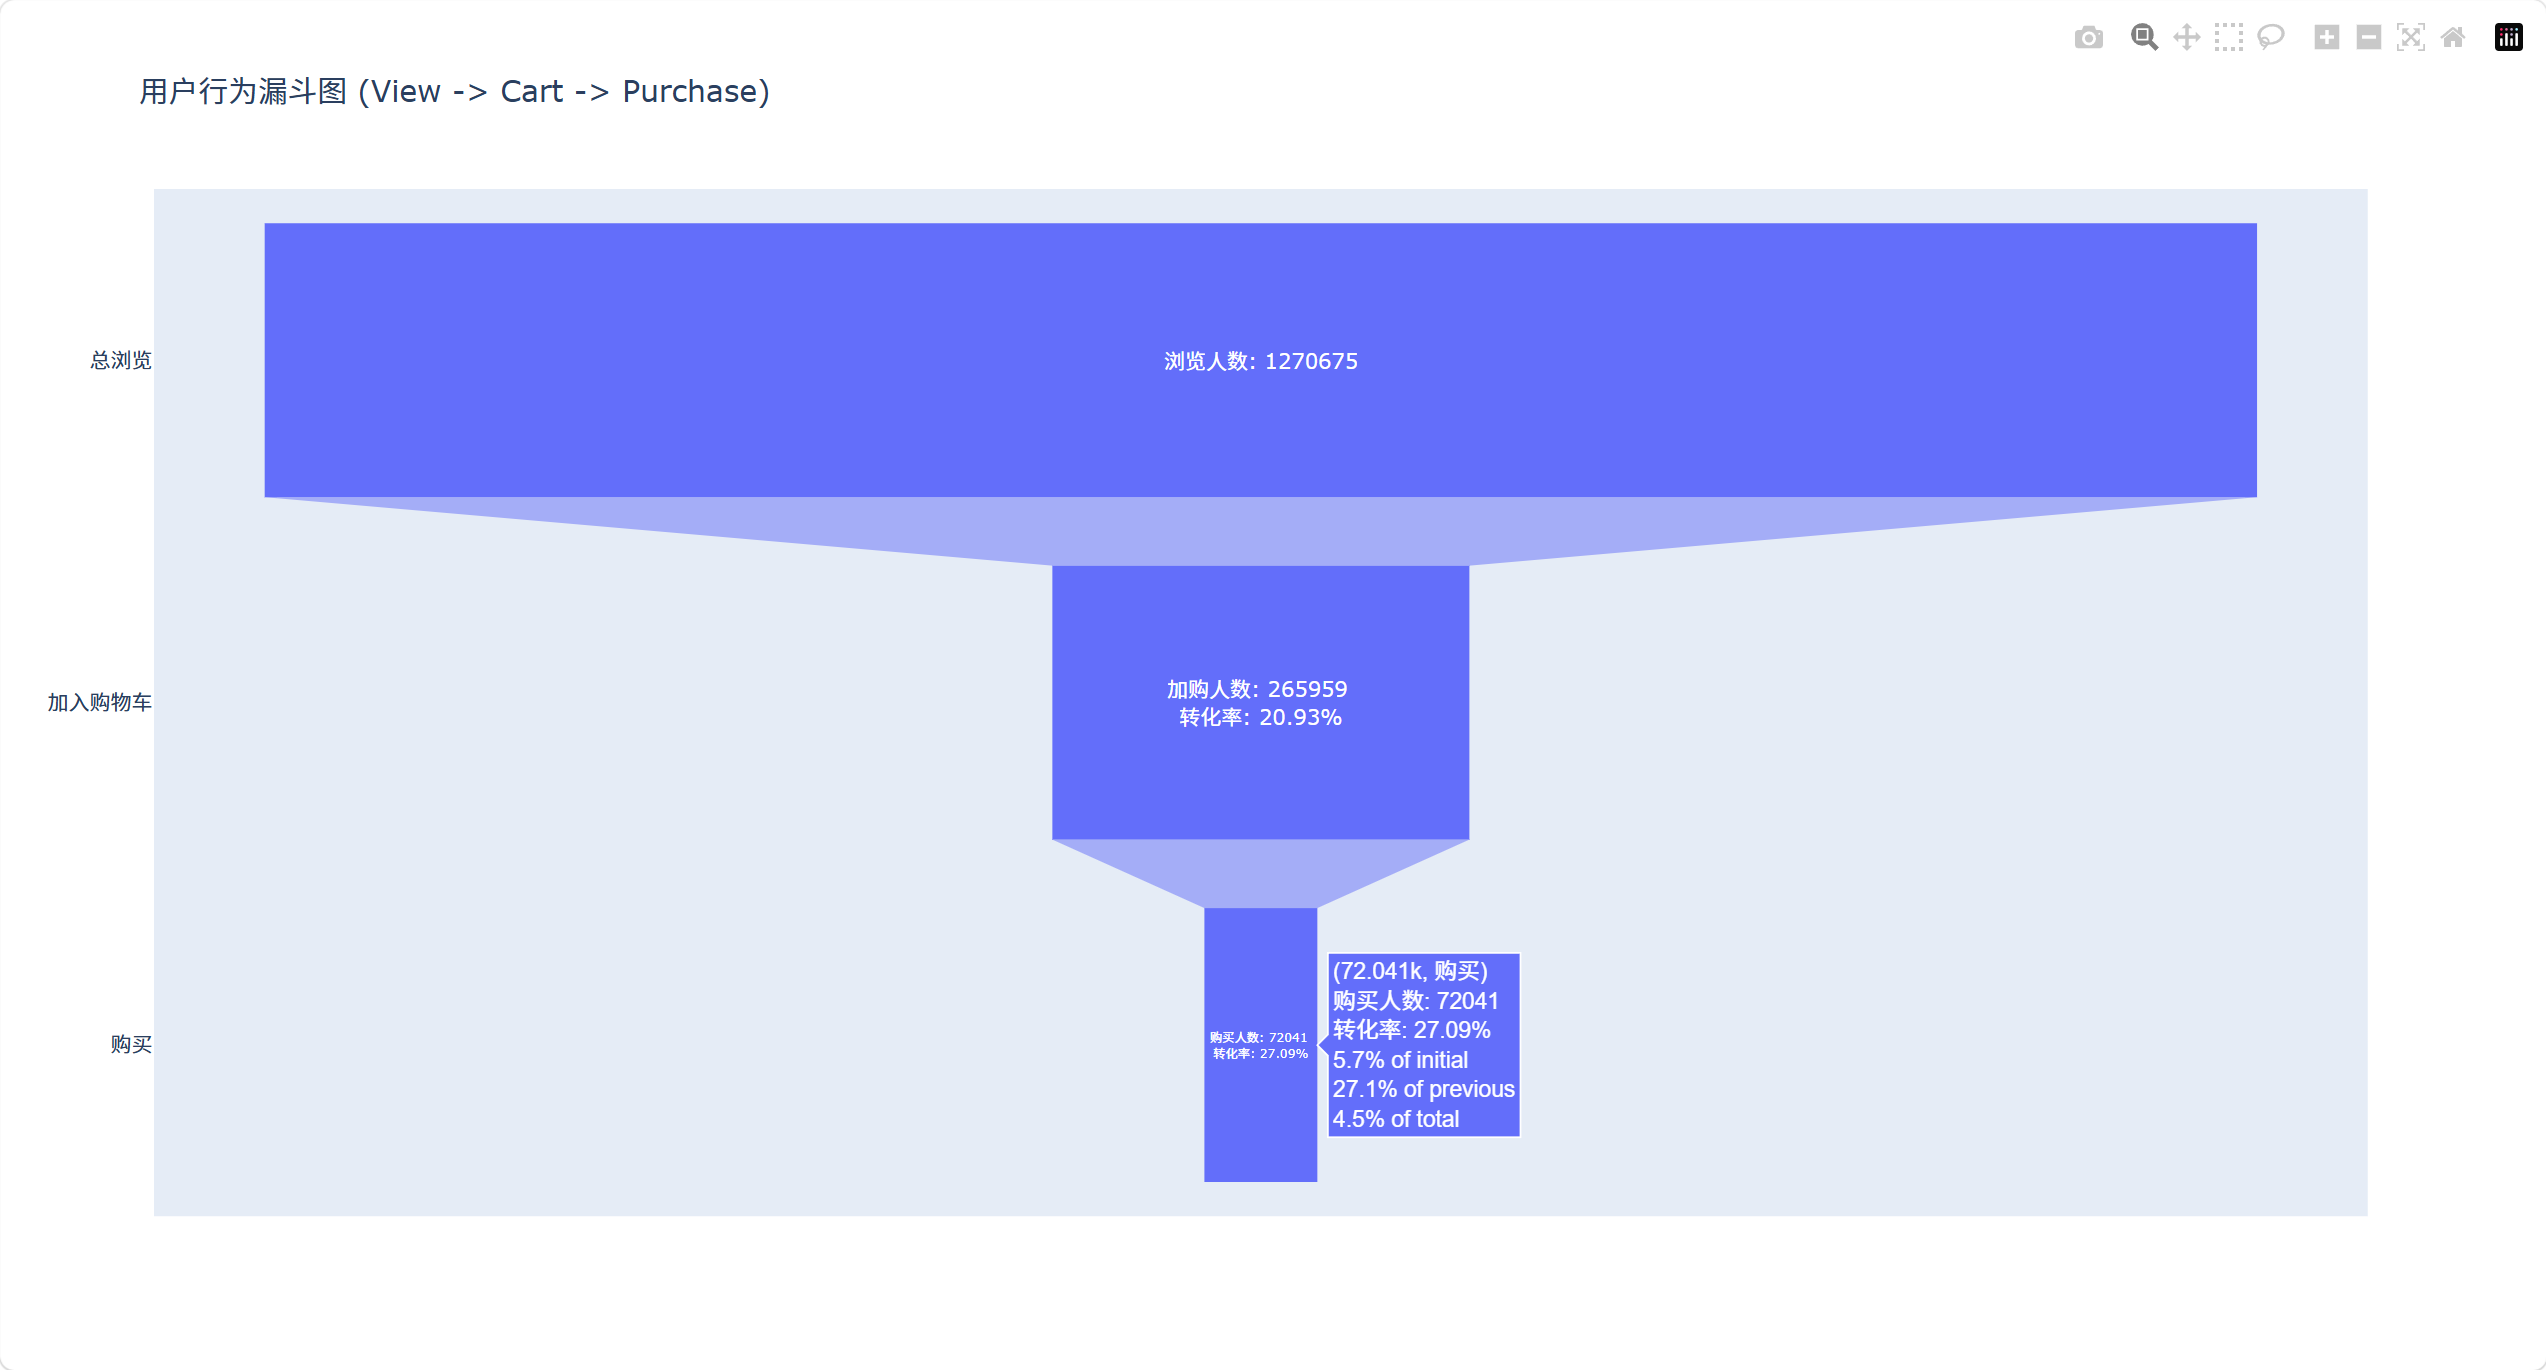

In [10]:
# 复用 funnel 图（直接引用已有图表）
from IPython.display import Image
Image(filename='../reports/02_user_funnel.png', width=700)

**核心数据**：
- 浏览 → 加购：转化率较高
- 加购 → 购买：仅 **23%** 完成支付
- 大量用户主动将商品从购物车移出（remove_from_cart 达 66.5 万次）

> **结论 1**：购物车环节是提升全站转化率的"胜负手"。  
> 接下来的分析锁定"加购但未购买"的用户，诊断流失根因。

---
## 发现二：价格不是用户放弃的原因

> 来源：`notebook 03 - AB入购行为对比`  
> 方法：将加购用户分为 A组（购买）和 B组（未购买），对比商品价格分布

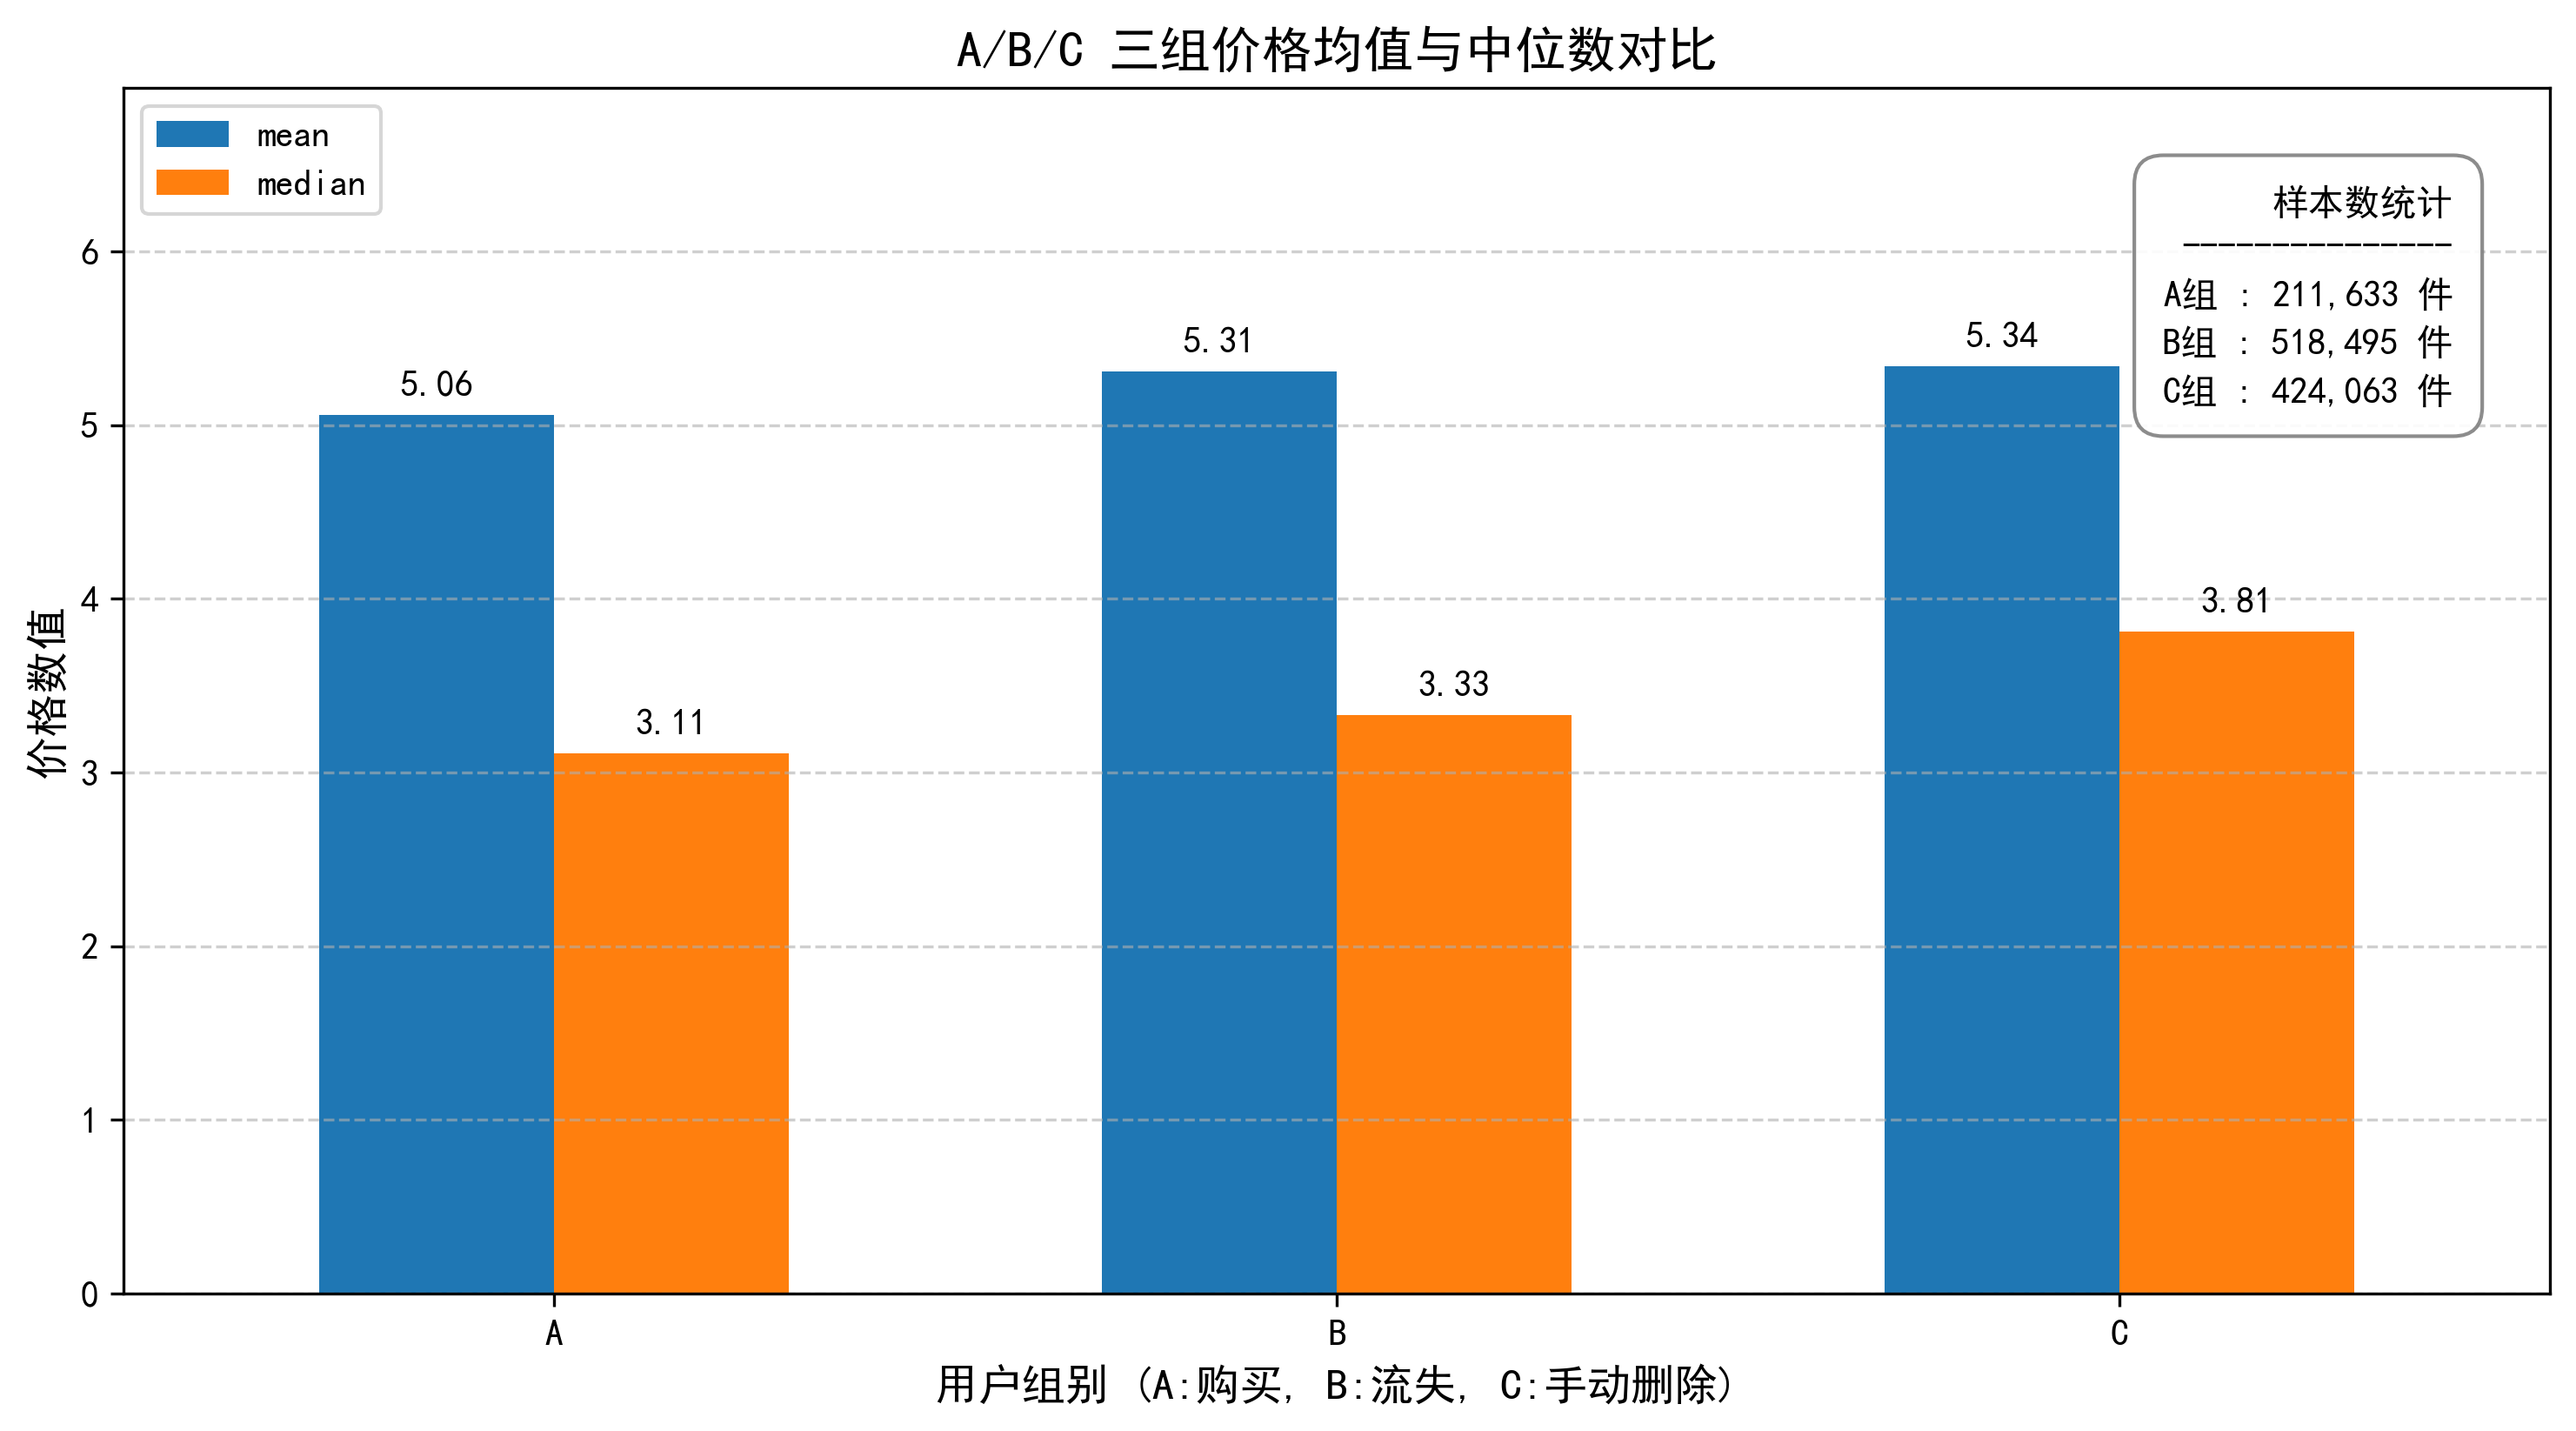

In [11]:
Image(filename='../reports/03_price_metrics_comparison.png', width=700)

**分析结果**：
- A组（转化用户）和 B组（流失用户）的商品单价分布 **高度重合**
- 购物车总金额也无显著差异

> **结论 2**：用户并非因为"太贵了"而放弃购物车。流失的根源需要从其他维度寻找。

---
## 发现三：品牌才是流失的根本差异因素

> 来源：`notebook 04 - ABC品牌维度分析`  
> 方法：将用户分为 A（购买）、B（被动流失-未操作）、C（主动流失-移出购物车），统计每个品牌的 ABC 占比

In [12]:
# 加载品牌ABC分析数据
df_brand = pd.read_csv('../data/interim/04_abc_brand_analysis.csv')

# 计算流失风险比 C/A
df_brand['C_over_A'] = df_brand['C'] / df_brand['A']
df_brand['C_over_A'] = df_brand['C_over_A'].replace([np.inf, -np.inf], np.nan)

# 只看有一定体量的品牌（A+B+C 合计 > 2%）
df_brand['total'] = df_brand['A'] + df_brand['B'] + df_brand['C']
df_main = df_brand[df_brand['total'] > 2].copy()

print(f'共有 {len(df_brand)} 个品牌，其中体量较大的有 {len(df_main)} 个')
df_main.sort_values('C_over_A', ascending=False)

共有 164 个品牌，其中体量较大的有 19 个


,brand,A,B,C,C_over_A,total
5,masura,3.26,3.93,5.02,1.539877,12.21
17,haruyama,0.82,0.95,1.15,1.402439,2.92
15,bluesky,0.95,1.23,1.31,1.378947,3.49
9,pole,1.44,1.45,1.68,1.166667,4.57
6,ingarden,1.95,2.07,2.24,1.148718,6.26
3,grattol,3.84,4.47,4.10,1.067708,12.41
11,freedecor,1.24,1.26,1.29,1.040323,3.79
0,Unknown Brand,43.01,44.19,44.48,1.034178,131.68
10,uno,1.30,1.15,1.19,0.915385,3.64
13,milv,1.05,0.95,0.95,0.904762,2.95


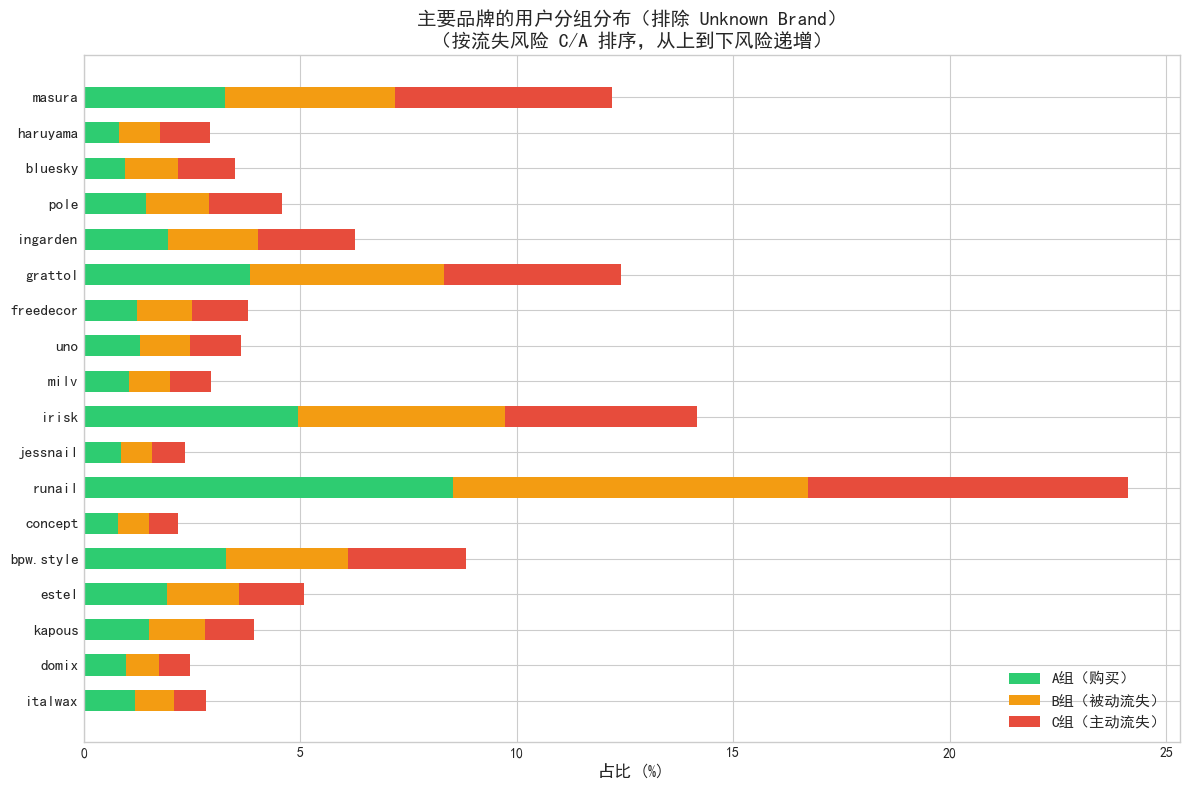

In [13]:
# 图1：主要品牌的 ABC 分布堆叠柱状图（排除 Unknown Brand）
df_plot = df_main[df_main['brand'] != 'Unknown Brand'].sort_values('C_over_A', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

y_pos = range(len(df_plot))
bars_a = ax.barh(y_pos, df_plot['A'], color=COLORS['A'], label='A组（购买）', height=0.6)
bars_b = ax.barh(y_pos, df_plot['B'], left=df_plot['A'], color=COLORS['B'], label='B组（被动流失）', height=0.6)
bars_c = ax.barh(y_pos, df_plot['C'], left=df_plot['A']+df_plot['B'], color=COLORS['C'], label='C组（主动流失）', height=0.6)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['brand'], fontsize=11)
ax.set_xlabel('占比 (%)', fontsize=12)
ax.set_title('主要品牌的用户分组分布（排除 Unknown Brand）\n（按流失风险 C/A 排序，从上到下风险递增）', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/07_brand_abc_stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()

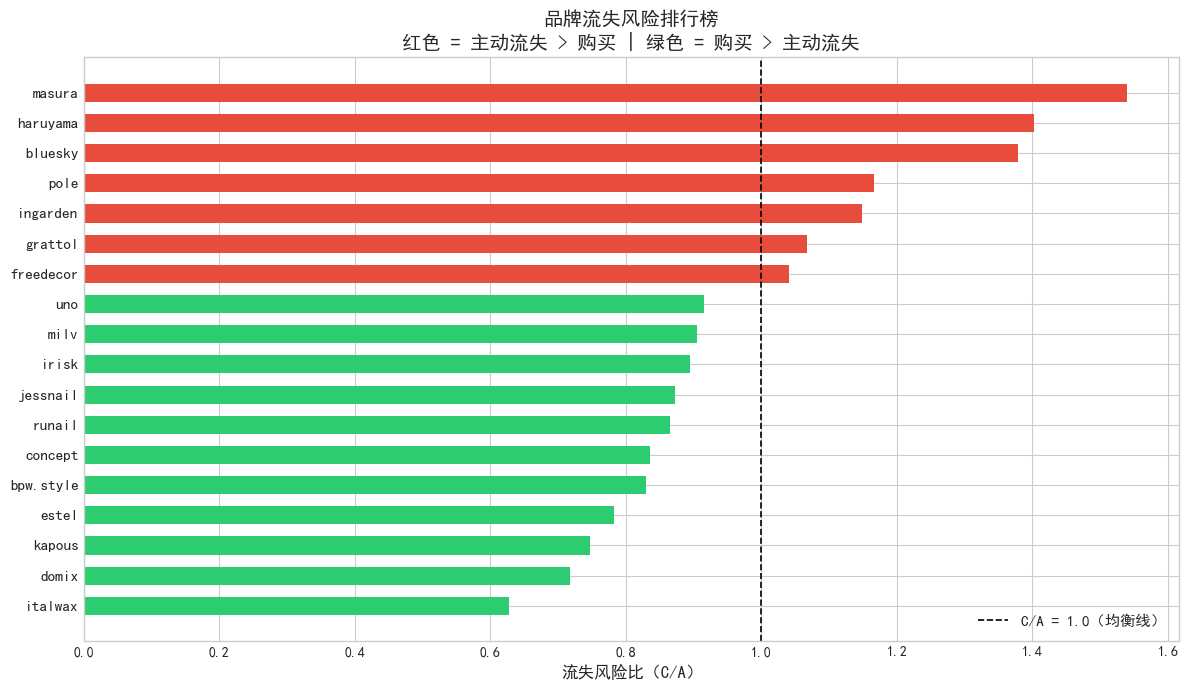

In [14]:
# 图2：流失风险比排行榜（C/A比值，排除 Unknown Brand）
df_risk = df_main[df_main['brand'] != 'Unknown Brand'].copy()
df_risk = df_risk.sort_values('C_over_A', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

colors_bar = ['#e74c3c' if x > 1 else '#2ecc71' for x in df_risk['C_over_A']]

bars = ax.barh(range(len(df_risk)), df_risk['C_over_A'], color=colors_bar, height=0.6)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.2, label='C/A = 1.0（均衡线）')

ax.set_yticks(range(len(df_risk)))
ax.set_yticklabels(df_risk['brand'], fontsize=11)
ax.set_xlabel('流失风险比（C/A）', fontsize=12)
ax.set_title('品牌流失风险排行榜\n红色 = 主动流失 > 购买 | 绿色 = 购买 > 主动流失', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../reports/07_brand_risk_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

**品牌两极分化现象**：

- **健康品牌（C/A < 1）**：`runail`、`estel`、`kapous`、`italwax`、`severina` 等 —— 买的人比主动放弃的人多
- **危险品牌（C/A > 1）**：`masura`、`bluesky`、`cosmoprofi`、`haruyama` 等 —— 主动放弃的人比买的人还多
- 其中 `masura` 最典型：C组占比（5.02%）是 A组占比（3.26%）的 **1.54 倍**

> **结论 3**：不同品牌的流失命运截然不同。品牌自身的特征（产品力、口碑、竞品替代性等）是决定用户是否最终购买的关键因素。

那么问题来了：**时间对流失的影响，是否也和品牌有关？** 我们用流失代表 `masura` 和购买代表 `runail` 做进一步验证。

---
## 发现四：时间影响转化，但不是根因

> 来源：`notebook 02` 时间分析 + `notebook 05 - 品牌时间交叉分析`  
> 方法：统计不同时段的加购/购买/流失比例，并与品牌交叉验证

首先回顾全站的时间分布规律：

**时间分布规律**：
- **购买高峰**：早上 6:00 - 11:00（用户决策果断）
- **流失高峰**：晚上 18:00 - 次日 4:00（加购多但支付少）

![时间分布](../reports/03_time_point_distribution1.png)

但这是否意味着"晚上购物就会流失"？我们进一步做了品牌×时间交叉分析：

![品牌时间交叉分析](../reports/05_brand_time_cross_analysis.png)

**交叉验证结论**：

| 品牌 | 时段 | A组(购买%) | C组(主动流失%) | C/A比值 |
|------|------|-----------|---------------|--------|
| masura | 上午 | 17.06 | 42.88 | **2.51** |
| masura | 晚上 | 13.06 | 44.02 | **3.37** |
| runail | 上午 | 22.34 | 34.40 | **1.54** |
| runail | 晚上 | 18.04 | 34.78 | **1.93** |

关键发现：masura 在**最好的时段**（上午）的流失风险（2.51），仍高于 runail 在**最差的时段**（晚上）的 1.93。

> **结论 4**：时间确实影响转化率，但**品牌本身的差异比时间更大**。时间只是加剧了品牌间已有的差距，而非创造差距。

---
## 总结：五大发现一览

| # | 发现 | 方法 | 排除/锁定 |
|---|------|------|----------|
| 1 | 购物车是最大流失黑洞 | 漏斗分析 | 锁定分析方向 |
| 2 | 价格不是流失原因 | AB组价格分布对比 | ❌ 排除价格 |
| 3 | 品牌是根本差异 | ABC品牌分组分析 | ✅ 锁定品牌 |
| 4 | 时间是影响因素但非根因 | 品牌×时间交叉分析 | ⚠️ 时间有影响，但非主因 |
| 5 | 同价不同命，品牌护城河存在 | 控制价格后的品牌对比 | ✅ 确认品牌本身特征 |

---
## 业务建议

基于以上五个发现，提出以下可落地的业务建议：

### 建议 1：对高流失品牌（masura 类）实施"加购挽回"策略

- **问题**：masura、bluesky、cosmoprofi 等品牌 C/A > 1，主动放弃率极高
- **动作**：用户加购这些品牌商品后 **2小时内**，推送限时优惠券或"同类热销商品"推荐
- **预期效果**：在用户还在犹豫时，用优惠/替代品降低决策门槛

### 建议 2：对健康品牌（runail 类）加大流量投入

- **问题**：runail、estel、kapous 等品牌转化率健康（C/A < 1），但曝光不一定够
- **动作**：在首页推荐、搜索结果中提升这些品牌的权重
- **预期效果**：这些品牌"给流量就能转化"，ROI 更高

### 建议 3：下午 16 点是精准促活的黄金窗口

- **问题**：16 点后流失率开始攀升，但此时用户仍活跃（加购量不低）
- **动作**：在 16:00 左右对购物车内有商品的活跃用户推送提醒（Push/App通知）
- **预期效果**：赶在流失高峰到来前"截胡"，将犹豫用户转化为购买用户

### 建议 4：关注高溢价品牌定价策略

- **问题**：masura 在 10-15 元价格带的 C/A 飙升至 6.1，完全没有溢价能力
- **动作**：与供应商协商，对缺乏品牌溢价的商品控制定价在 10 元以下，或搭配赠品提升感知价值
- **预期效果**：避免用户因"这个牌子不值这个价"而流失

---
## 局限性（诚实声明）

1. **数据时间范围有限**：仅 2019 年 12 月一个月，无法观察季节性变化和长期趋势
2. **品类单一**：化妆品电商，结论可能不适用于其他品类（如3C、食品）
3. **缺少用户画像**：没有年龄、性别、地域等信息，无法做用户分群
4. **缺少评价数据**：推测品牌差异与产品评价/口碑有关，但数据中无评价字段，无法直接验证
5. **未做统计显著性检验**：品牌间的 C/A 差异未做卡方检验，小样本品牌的结论需谨慎对待
6. **"Unknown Brand" 占比较大**（约 44%），可能掩盖了部分真实品牌的差异

### 未来可深入的方向

- 竞品共现分析：用户在同一 session 里加购了 masura 后又加购了谁？谁抢走了订单？
- 用户行为序列：流失前用户浏览了什么？（比如是否看了同类更便宜的商品）
- 复购分析：流失用户之后是否回来买了其他品牌？
- 预测模型：基于 session 特征预测一次加购是否会流失

# 导出为 Markdown 报告
report_md = """# 电商购物车流失分析报告：为什么用户加购后不买？

> 数据来源：Kaggle - Ecommerce Events History（化妆品电商，2019年12月）  
> 数据规模：100万+ 事件记录 | 166 个品牌  
> 分析方法：漏斗分析 → 排除法 → 交叉验证

---

## 一、核心发现

### 发现 1：购物车是全站最大的流失黑洞

加购用户仅 **23%** 最终完成购买，77% 的加购行为以流失告终。  
其中大量用户主动将商品从购物车移出（remove_from_cart 达 66.5 万次）。

![转化漏斗](02_user_funnel.png)

### 发现 2：价格不是流失原因

对比"转化用户"与"流失用户"的商品单价分布，两组 **高度重合**。  
用户并非因为"太贵了"而放弃购物车。

![价格对比](03_price_metrics_comparison.png)

### 发现 3：品牌是流失的根本差异因素

不同品牌的流失命运截然不同：

| 品牌类型 | 代表品牌 | 特征 |
|---------|---------|------|
| 健康品牌（C/A < 1） | runail, estel, kapous | 买的人比弃的人多 |
| 危险品牌（C/A > 1） | masura, bluesky, cosmoprofi | 弃的人比买的人还多 |

### 发现 4：时间影响转化，但不是根因

- 购买高峰：早上 6:00 - 11:00
- 流失高峰：晚上 18:00 - 次日 4:00

但品牌×时间交叉分析发现：**masura 在最好时段的流失风险（2.51）仍高于 runail 在最差时段（1.93）**。  
时间只是加剧了品牌间已有的差距，而非创造差距。

### 发现 5：同价不同命——品牌护城河确实存在

即使在同一价格带内，masura 的流失率稳定是 runail 的 **1.5 倍**。  
高溢价区（10-15元）masura 的流失风险比飙升至 **6.1**。  
**问题不在价格，而在品牌本身的产品力和用户心智。**

![价格品牌分析](06_price_brand_group_analysis.png)

---

## 二、业务建议

### 建议 1：高流失品牌实施"加购挽回"
对 masura、bluesky 等 C/A > 1 的品牌，用户加购后 2 小时内推送限时优惠券。

### 建议 2：健康品牌加大流量投入
对 runail、estel 等 C/A < 1 的品牌，在首页推荐和搜索结果中提升权重——这些品牌"给流量就能转化"。

### 建议 3：16 点是精准促活的黄金窗口
在下午 16:00 左右对购物车内有商品的活跃用户推送提醒，赶在流失高峰前截胡。

### 建议 4：控制弱品牌定价
对缺乏品牌溢价能力的商品控制定价在 10 元以下，或搭配赠品提升感知价值。

---

## 三、局限性

1. 数据仅覆盖 2019 年 12 月一个月，无法观察长期趋势
2. 品类单一（化妆品），结论不一定适用于其他品类
3. 缺少用户画像（年龄/性别/地域）和评价数据
4. 未对品牌差异做统计显著性检验
"""

with open('../reports/final_report.md', 'w', encoding='utf-8') as f:
    f.write(report_md)

print('报告已导出到 reports/final_report.md')